# Homework 2 - PHYS 512

Élyse D'Aoust

261335942

## Question 1 - Midpoint method

Part a)

At time $t_n$, we know $y(t_n)$ and want to step forward in time to find $y(t_n+h)$.

Using a Taylor series expansion of $y(t_n+h)$ about $t_n$, we have:

$$
y(t_n+h) = \sum_{i=0}^{\infty} \frac{h^i}{i!}y^{(i)}(t_n)
$$
Writing this out gives (grouping third order and higher terms into $O(h^3)$):
$$
y(t_n+h)≈y(t_n)+h y'(t_n)+\frac{h^2}{2}y''(t_n)+O(h^3).
$$

Knowing $\frac{dy}{dt}=f(t,y)$ and $y'(t_n)=f(t_n,y(t_n))=f_n$, we get:
$$
y(t_n+h)≈y(t_n)+h f_n+ \frac{h^2}{2}(\frac{d}{dt} f(t_n,y_n))+O(h^3).
$$

Using the chain rule for $\frac{d}{dt} f(t_n,y_n)$:
$$
y(t_n+h)≈y(t_n)+h f_n+ \frac{h^2}{2}(\left.\frac{\partial f}{\partial t}\right|_n+\left.\frac{\partial f}{\partial y}\right|_n \left.\frac{dy}{dt}\right|_n)+O(h^3)
$$
$$
y(t_n+h)≈y(t_n)+h f_n+ \frac{h^2}{2}(\left.\frac{\partial f}{\partial t}\right|_n+\left.\frac{\partial f}{\partial y}\right|_n f_n)+O(h^3)
$$

Which is the expected result.

Part b)

For the explicit midpoint method, we know that $y_{n+1} = y_n +h f(t_n + \frac{h}{2}, y_n + \frac{h}{2} f_n)$.

Let's do a 2-dimensional Taylor expansion of $f(t_n + \frac{h}{2}, y_n + \frac{h}{2} f_n)$ about the point $(t_n, y(t_n))$. We have, for a function with two variables:

$$
f(x_0+\Delta x,\; y_0+\Delta y)≈f(x_0,y_0)+\left.\frac{\partial f}{\partial x}\right|_0 \Delta x+\left.\frac{\partial f}{\partial y}\right|_0 \Delta y+\frac{1}{2}\left[\left.\frac{\partial^2 f}{\partial x^2}\right|_0 (\Delta x)^2+2\left.\frac{\partial^2 f}{\partial x \partial y}\right|_0 \Delta x \Delta y+\left.\frac{\partial^2 f}{\partial y^2}\right|_0 (\Delta y)^2\right]+O(\Delta^3)
$$

In our case, we have:

$$
f\left(t_n+\frac{h}{2},\;y_n+\frac{h}{2}f_n\right)≈f(t_n,y_n)+\left.\frac{\partial f}{\partial t}\right|_n \frac{h}{2}+\left.\frac{\partial f}{\partial y}\right|_n \frac{h}{2}f_n+\frac{1}{2}\left[\left.\frac{\partial^2 f}{\partial t^2}\right|_n\left(\frac{h}{2}\right)^2+2\left.\frac{\partial^2 f}{\partial t \partial y}\right|_n\left(\frac{h}{2}\right)
\left(\frac{h}{2}f_n\right)+\left.\frac{\partial^2 f}{\partial y^2}\right|_n\left(\frac{h}{2}f_n\right)^2\right]+O(h^3)
$$

Since in our update step we multiply $f(t_n + \frac{h}{2}, y_n + \frac{h}{2} f_n)$ by $h$, and the third term in the equation above is of order $h^2$, we can neglect this term and higher order terms knowing that they will be fitting into $O(h^3)$. So, we have:

$$
f\left(t_n+\frac{h}{2},\;y_n+\frac{h}{2}f_n\right)≈f(t_n,y_n)+\left.\frac{\partial f}{\partial t}\right|_n \frac{h}{2}+\left.\frac{\partial f}{\partial y}\right|_n \frac{h}{2}f_n+O(h^2)
$$

Now, substituting this update back into the explicit midpoint formula gives:

$$
y_{n+1} ≈ y(t_n) +h [f(t_n,y_n)+\left.\frac{\partial f}{\partial t}\right|_n \frac{h}{2}+\left.\frac{\partial f}{\partial y}\right|_n \frac{h}{2}f_n+O(h^2)]
$$

$$
y_{n+1} ≈ y(t_n) +h f_n + \frac{h^2}{2} [\left.\frac{\partial f}{\partial t}\right|_n +\left.\frac{\partial f}{\partial y}\right|_n f_n)] +O(h^3)
$$

Comparing this to the result found in part a), we can see that they agree for all terms up to $h^2$.

Let's now look at the next term for both methods.

For the exact Taylor expansion, the next term is:

$$
\frac{h^3}{6}y'''(t_n)
$$

For the explicit midpoint method, the next term is:

$$
\frac{h^3}{8}\left(f_{tt}+2f_{ty}f_n+f_{yy}f_n^2\right)
$$

Therefore, we see that the explicit midpoint method differs from the exact solution starting at terms of order $h^3$, meaning that it has a local truncation error of $O(h^3)$.

Part c)

The midpoint method is described as a second order integrator even though local truncation error is $O(h^3)$, because over a fixed integration time, the number of timesteps is proportional to $1/h$. Therefore, the accumulated global error scales approximately as:

$$
\frac{1}{h}O(h^3)=O(h^2)
$$

Therefore, even though the local error is of $O(h^3)$, the global error is of $O(h^2)$ (and the order of an integrator refers to the order of its global error).

## Question 2

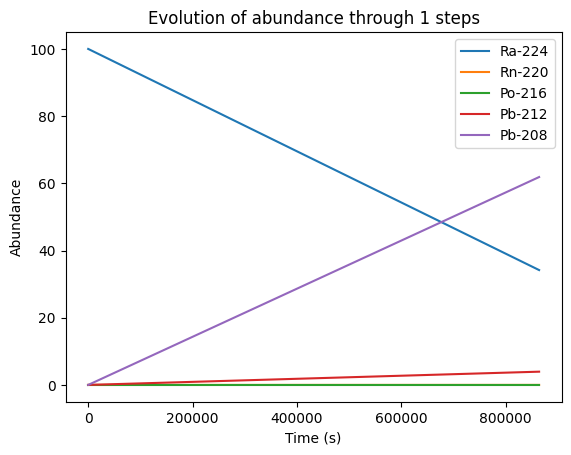

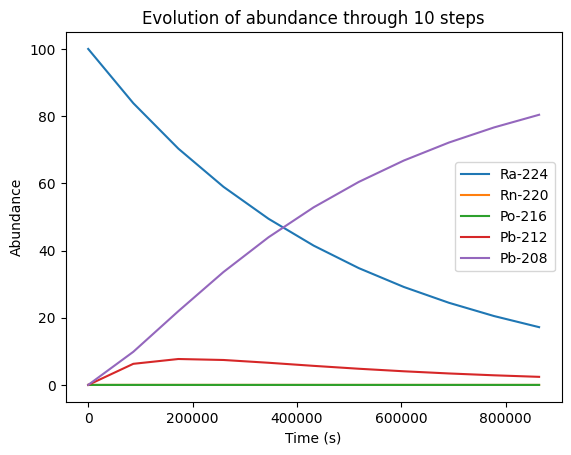

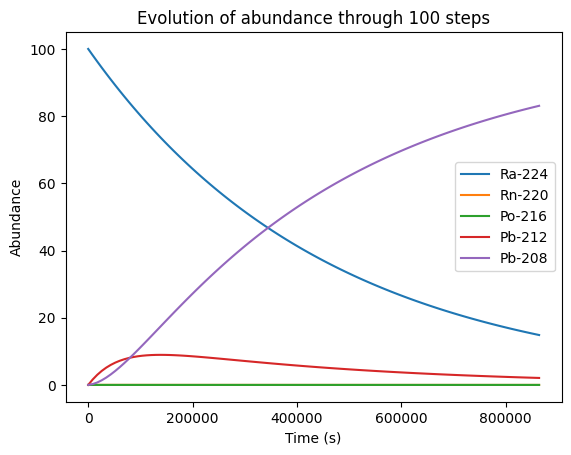

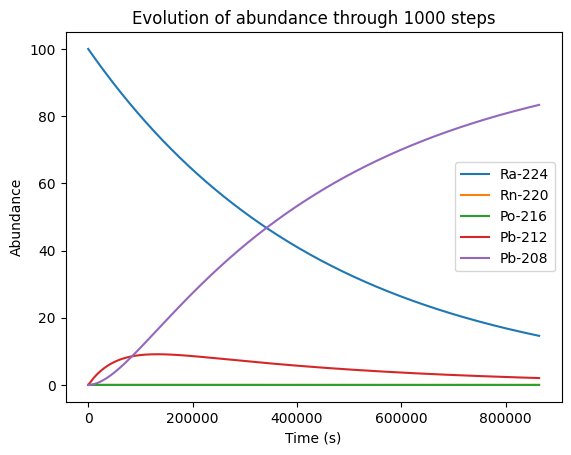

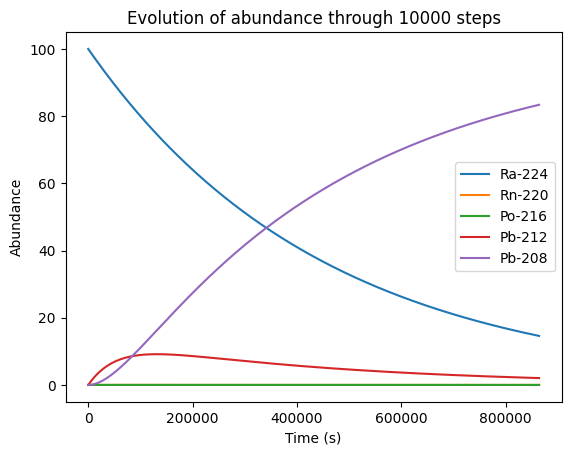

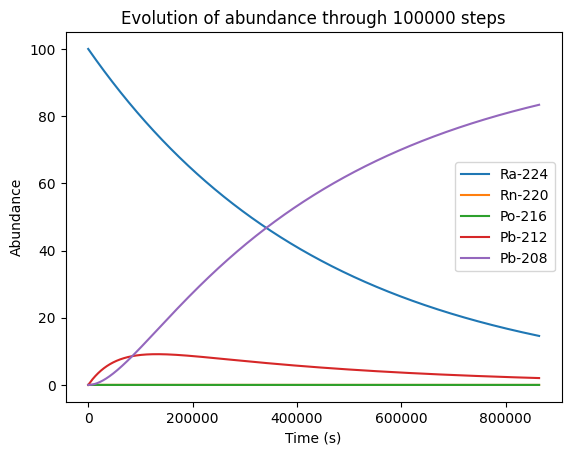

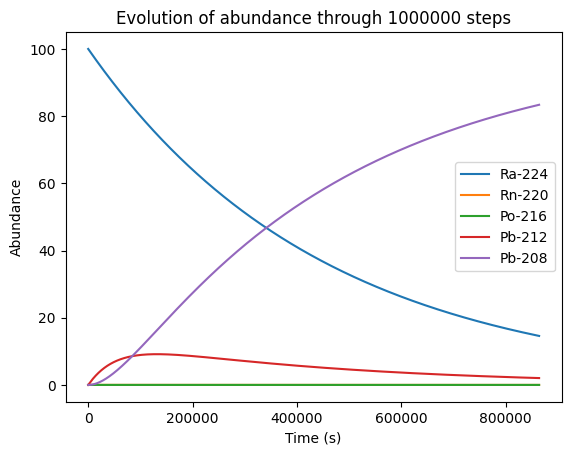

Rn-220 to Ra-224 abundance ratio:  0.0001768574046979747
Rn-220 to Ra-224 half-life ratio:  0.0001768261316872428
Po-216 to Rn-220 abundance ratio:  0.0025454556911714845
Po-216 to Rn-220 half-life ratio:  0.0025454545454545456
Pb-212 to Po-216 abundance ratio:  310687.9513226966
Pb-212 to Po-216 half-life ratio:  272571.4285714285


In [73]:
import numpy as np
import matplotlib.pyplot as plt

def backward_euler_decay(nsteps, dt, N0, decay_rates):
    x = np.zeros((nsteps+1,len(N0))) # matrix of abundances throughout evolution
    x[0] = N0 # set initial conditions

    # Diagonal and lower diagonal for coefficient matrix (based on decay rates)
    diagonal = np.append(-decay_rates,0)
    lower_diagonal = decay_rates

    # Matrix of coefficients
    C = (np.diag(diagonal, k=0) + np.diag(lower_diagonal, k=-1))

    A = np.linalg.inv(np.identity(len(N0)) - dt*C) # implicit update (minus sign because I used C instead of -C)

    for i in range(1,nsteps+1):
        x[i] = A@x[i-1]

    return x

# Decay rate for each element (ln(2)/(t_1/2))
c1 = np.log(2)/311040
c2 = np.log(2)/55
c3 = np.log(2)/0.14
c4 = np.log(2)/38160

# Array of decay rates
decay_rates = np.array([c1, c2, c3, c4])

# Initial state (pure Ra-224)
N0 = np.array([100,0,0,0,0])

t_end = 864000 # total time (10 days in seconds)
nsteps = [1, 10, 100, 1000, 10000, 100000, 1000000] # number of steps

for num in nsteps:
    dt = t_end/num # timestep
    result = backward_euler_decay(num, dt, N0, decay_rates)

    # Array of time stamps
    t = dt * np.arange(num+1)

    # Plotting
    plt.plot(t, result[:,0], label='Ra-224')
    plt.plot(t, result[:,1], label='Rn-220')
    plt.plot(t, result[:,2], label='Po-216')
    plt.plot(t, result[:,3], label='Pb-212')
    plt.plot(t, result[:,4], label='Pb-208')
    plt.xlabel("Time (s)")
    plt.ylabel("Abundance")
    plt.title(f'Evolution of abundance through {num} steps')
    plt.legend()
    plt.show()

    
# Calculate half-life ratios for the last result (using 1000000 steps), and compare to abundance ratios

# Abundance ratios
Rn220_Ra224_ratio = result[-1,1]/result[-1,0]
Po216_Rn220_ratio = result[-1,2]/result[-1,1]
Pb212_Po216_ratio = result[-1,3]/result[-1,2]

# Half-life ratios
Rn220_Ra224_hl_ratio = 55/311040
Po216_Rn220_hl_ratio = 0.14/55
Pb212_Po216_hl_ratio = 38160/0.14

print("Rn-220 to Ra-224 abundance ratio: ", Rn220_Ra224_ratio)
print("Rn-220 to Ra-224 half-life ratio: ", Rn220_Ra224_hl_ratio)
print("Po-216 to Rn-220 abundance ratio: ", Po216_Rn220_ratio)
print("Po-216 to Rn-220 half-life ratio: ", Po216_Rn220_hl_ratio)
print("Pb-212 to Po-216 abundance ratio: ", Pb212_Po216_ratio)
print("Pb-212 to Po-216 half-life ratio: ", Pb212_Po216_hl_ratio)

As Ra-224 decays, the daughter products initially increase from zero. Since Rn-220 and Po-216 have very short half-lives, these elements stay at very small abundances throughout the evolution (since they rapidly decay into the next element in the chain). Since the half-life of Pb-212 is much longer, it becomes more abundant more noticeably, but keeps decaying as time goes on. Finally, since Pb-208 is stable, it only accumulates throughout the evolution as the other elements decay. For very large timesteps, some features of the evolution for some of the elements are not resolved. For example, for 1 timestep only, the buildup and decline of Pb-212 is completely missed. As the timestep is reduced, the abundance curves converge towards smoother solutions. For a timestep of 0.864 s, we can see that agreements between half-life ratios and abundance ratios for parent and daughter isotopes are in good agreement for elements that will have time to reach approximate equilibrium with their parent abundance (notably Rn-220 and Po-216), which confirms the accuracy of the numerical results.

## Question 3

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# Implicit midpoint method (code adapted from backward-Euler solution code in class notes)

def implicit_midpoint(nsteps):
    
    t_end = 2*np.pi * 10
    h = t_end/nsteps

    # Initial conditions
    theta = np.zeros(nsteps+1)
    omega = np.zeros(nsteps+1)

    theta[0] = np.pi/2    # initial angle (radians)
    omega[0] = 0.0

    # Newton parameters
    tol = 1e-3
    max_iter = 10

    for n in range(nsteps):
        
        # Initial guess for theta_{n+1}, omega_{n+1}
        # Use the previous timestep as the initial guess
        x = np.array([theta[n], omega[n]])

        # Newton iterations
        for k in range(max_iter):

            th, om = x
    
            # Calculated F(y), given that for the implicit method we have y_n+1 = y_n + h*f((y_n + y_n+1)/2) and that y = (theta, omega)
            F = np.array([th - theta[n] - h * ((omega[n] + om)/2), om - omega[n] + h * np.sin((theta[n] + th)/2)])

            # Calculated Jacobian matrix
            J = np.array([[1.0,  -h/2],[(h/2)*np.cos((theta[n]+th)/2),  1.0]])

            # solve for delta y and update
            delta = np.linalg.solve(J, -F)
            x += delta
            
            # Check convergence
            if np.linalg.norm(delta) < tol:
                break

        # Store converged solution
        theta[n+1] = x[0]
        omega[n+1] = x[1]

    return theta, omega

In [45]:
# Crank-Nicolson method (code adapted from backward-Euler solution code in class notes)

def crank_nicolson(nsteps):
    
    t_end = 2*np.pi * 10
    h = t_end/nsteps

    # Initial conditions
    theta = np.zeros(nsteps+1)
    omega = np.zeros(nsteps+1)

    theta[0] = np.pi/2    # initial angle (radians)
    omega[0] = 0.0

    # Newton parameters
    tol = 1e-3
    max_iter = 10

    for n in range(nsteps):
        
        # Initial guess for theta_{n+1}, omega_{n+1}
        # Use the previous timestep as the initial guess
        x = np.array([theta[n], omega[n]])

        # Newton iterations
        for k in range(max_iter):

            th, om = x

            # Calculated F(y), given that for the Crank-Nicolson method we have y_n+1 = y_n + (h/2)*[f(y_n) + f(y_n+1)] and that y = (theta, omega)
            F = np.array([th - theta[n] - (h/2)*(omega[n] + om), om - omega[n] + (h/2)*(np.sin(theta[n]) + np.sin(th))])

            # Calculated Jacobian matrix
            J = np.array([[1.0,  -(h/2)],[(h/2)* np.cos(th),  1.0]])

            # solve for delta y and update
            delta = np.linalg.solve(J, -F)
            x += delta
            
            # Check convergence
            if np.linalg.norm(delta) < tol:
                break

        # Store converged solution
        theta[n+1] = x[0]
        omega[n+1] = x[1]

    return theta, omega

In [46]:
# Backward Euler method (from class solutions)

def bacward_euler(nsteps):
    
    t_end = 2*np.pi * 10
    h = t_end/nsteps

    # Initial conditions
    theta = np.zeros(nsteps+1)
    omega = np.zeros(nsteps+1)

    theta[0] = np.pi/2    # initial angle (radians)
    omega[0] = 0.0

    # Newton parameters
    tol = 1e-3
    max_iter = 10

    for n in range(nsteps):
        
        # Initial guess for theta_{n+1}, omega_{n+1}
        # Use the previous timestep as the initial guess
        x = np.array([theta[n], omega[n]])

        # Newton iterations
        for k in range(max_iter):

            th, om = x
    
            F = np.array([th - theta[n] - h * om, om - omega[n] + h * np.sin(th)])
            J = np.array([[1.0,  -h],[h * np.cos(th),  1.0]])

            # solve for delta y and update
            delta = np.linalg.solve(J, -F)
            x += delta

            #print('iteration %d, delta = %lg' % (k, np.linalg.norm(delta)))
            
            # Check convergence
            if np.linalg.norm(delta) < tol:
                break

        # Store converged solution
        theta[n+1] = x[0]
        omega[n+1] = x[1]

        # Explicit
        # (uncomment to use the explicit update instead of the implicit one)
        #theta[n+1] = theta[n] + h*omega[n]
        #omega[n+1] = omega[n] - h*np.sin(theta[n])

    return theta, omega

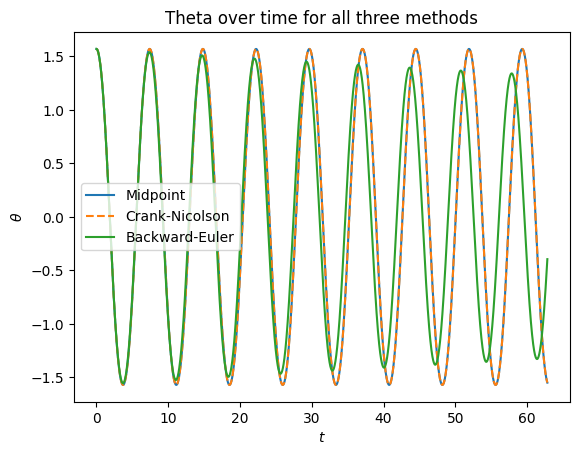

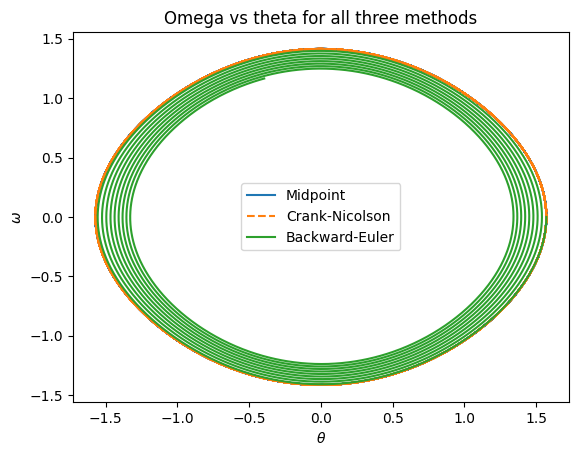

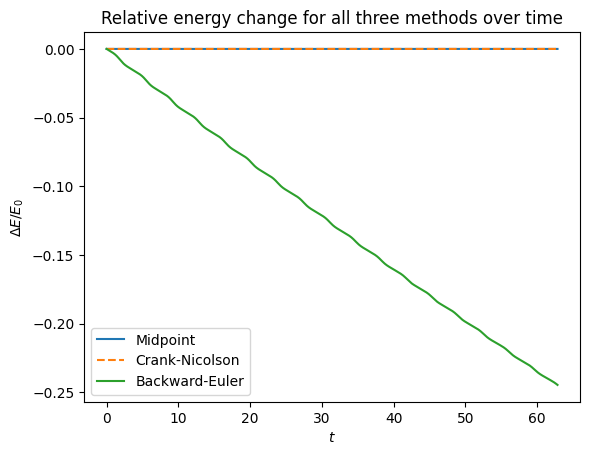

In [52]:
# Plot the solutions for all three methods

nsteps = 10000 # define number of steps
t_end = 2*np.pi * 10 # end time

t = np.linspace(0, t_end, nsteps+1) # get time stamps

# Get theta and omega for each method with given number of steps
theta_midpoint, omega_midpoint = implicit_midpoint(nsteps)
theta_cn, omega_cn = crank_nicolson(nsteps)
theta_be, omega_be = bacward_euler(nsteps)

# Plotting 
plt.plot(t, theta_midpoint, label='Midpoint')
plt.plot(t, theta_cn, label='Crank-Nicolson', linestyle='--')
plt.plot(t, theta_be, label='Backward-Euler')
plt.xlabel(r'$t$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.title("Theta over time for all three methods")
plt.show()

plt.figure()
plt.plot(theta_midpoint,omega_midpoint, label='Midpoint')
plt.plot(theta_cn,omega_cn, label='Crank-Nicolson', linestyle='--')
plt.plot(theta_be,omega_be, label='Backward-Euler')
plt.ylabel(r'$\omega$')
plt.xlabel(r'$\theta$')
plt.legend()
plt.title("Omega vs theta for all three methods")
plt.show()

plt.figure()
# Calculate energy of the nonlinear pendulum for all three methods
E1 = (1/2)*(omega_midpoint**2) + 1 - np.cos(theta_midpoint)
E2 = (1/2)*(omega_cn**2) + 1 - np.cos(theta_cn)
E3 = (1/2)*(omega_be**2) + 1 - np.cos(theta_be)
plt.plot(t, (E1-E1[0])/E1[0], label='Midpoint')
plt.plot(t, (E2-E2[0])/E2[0], label='Crank-Nicolson', linestyle='--')
plt.plot(t, (E3-E3[0])/E3[0], label='Backward-Euler')
plt.ylabel(r'$\Delta E/E_0$')
plt.xlabel(r'$t$')
plt.legend()
plt.title("Relative energy change for all three methods over time")
plt.show()

From the three plots above, we can see that the implicit midpoint and Crank-Nicolson methods give nearly identical results for 10000 steps, and that they both preserve the oscillation amplitude (no apparent damping) and the energy very well over time. The backward-Euler results from class showed apparent damping in the amplitude, a phase-space trajectory that spirals inwards, as well as a decreasing energy through time evolution. This is not an expected behaviour for the given pendulum scenario, since the energy is expected to be conserved and no damping is expected. Therefore, this shows that the two second-order methods (implicit midpoint and Crank-Nicolson) represent the behaviour of the non-linear pendulum much more accurately.

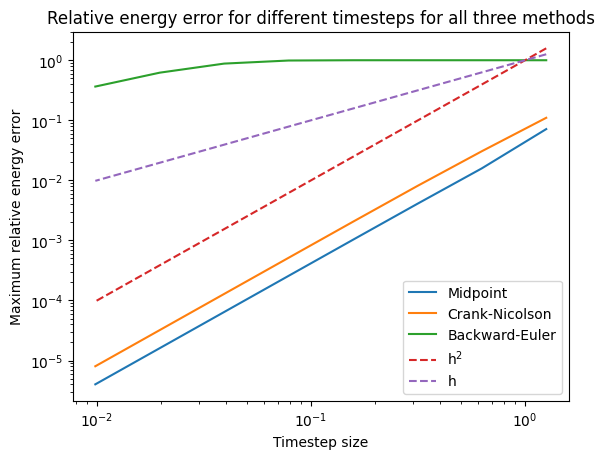

In [72]:
# Show that the error scales as h^2 for the two methods, to show that they are 2nd order integrators

num_steps = np.array([50, 100, 200, 400, 800, 1600, 3200, 6400]) # different number of steps
t_end = 2*np.pi * 10 # end time

# Define empty arrays to store results
h_val = []
err_midpoint = []
err_cn = []
err_be = []

for n in num_steps:
    h = t_end/n # calculate timestep
    h_val.append(h)

    # Get results for theta and omega for each method
    theta_m, omega_m = implicit_midpoint(n)
    theta_cn, omega_cn = crank_nicolson(n)
    theta_be, omega_be = bacward_euler(n)

    # Calculate the energy for each method
    E_m = (1/2)*(omega_m**2) + 1 - np.cos(theta_m)
    E_cn = (1/2)*(omega_cn**2) + 1 - np.cos(theta_cn)
    E_be = (1/2)*(omega_be**2) + 1 - np.cos(theta_be)

    # Calculate the maximum relative errors for each method based on energy conservation
    error_m = np.abs((E_m - E_m[0])/E_m[0])
    err_midpoint.append(np.max(error_m))

    error_cn = np.abs((E_cn - E_cn[0])/E_cn[0])
    err_cn.append(np.max(error_cn))

    error_be = np.abs((E_be - E_be[0])/E_be[0])
    err_be.append(np.max(error_be))

# Plotting
plt.loglog(h_val, err_midpoint, label='Midpoint')
plt.loglog(h_val, err_cn, label='Crank-Nicolson')
plt.loglog(h_val, err_be, label='Backward-Euler')
plt.loglog(h_val, (np.array(h_val)**2), label='h$^2$', linestyle='--') # y = h^2 reference
plt.loglog(h_val, np.array(h_val), label='h', linestyle='--') # y = h reference
plt.xlabel("Timestep size")
plt.ylabel('Maximum relative energy error')
plt.title("Relative energy error for different timesteps for all three methods")
plt.legend()
plt.show()

From the above plot, we can therefore confirm that the implicit midpoint and Crank-Nicolson methods are indeed 2nd order integrators, since plotting their maximum relative error against the size of the timestep shows that the error for both methods scales approximately like $h^2$. Indeed, by looking at the reference line for $y = h^2$, we can see that the slopes for the relative energy error for both methods in the log-log plot seem to match very well. On the other hand, the backward-Euler method does not show the same scaling, and produces much larger errors.